In [55]:
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.io import read_image

from src.models.resnet import ResNet
from src.dataset import SatelliteDataset, get_eval_transforms

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading Trained Model

In [47]:
MODEL_DIR = 'models'

print("Avaliable trained models:\n")

model_files = []

for entry in os.listdir(MODEL_DIR):
    if not os.path.isdir(entry):
        model_files.append(entry)

display(model_files)

Avaliable trained models:



['ResNet_2025-12-06-16:03.pth']

## Getting Test Predictions

In [50]:
model_filepath = os.path.join(MODEL_DIR, model_files[0])
model = ResNet(in_channels=3, n_classes=4)
model.load_state_dict(torch.load(model_filepath))

test_loader = DataLoader(
    dataset=SatelliteDataset(file="artifacts/test.csv", transforms=get_eval_transforms()),
    batch_size=16,
)

predicted = []
expected = []

for X, Y in test_loader:
    predicted.append(model(X).argmax(dim=1)) 
    expected.append(Y)
    
predicted = torch.cat(predicted).numpy()
expected = torch.cat(expected).numpy()

## Classification Report

In [59]:
from sklearn.metrics import classification_report
print(classification_report(predicted, expected, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.9942    0.9971       172
           1     0.9909    1.0000    0.9954       109
           2     0.9930    0.9930    0.9930       143
           3     0.9929    0.9929    0.9929       140

    accuracy                         0.9947       564
   macro avg     0.9942    0.9950    0.9946       564
weighted avg     0.9947    0.9947    0.9947       564



## Confusion Matrix

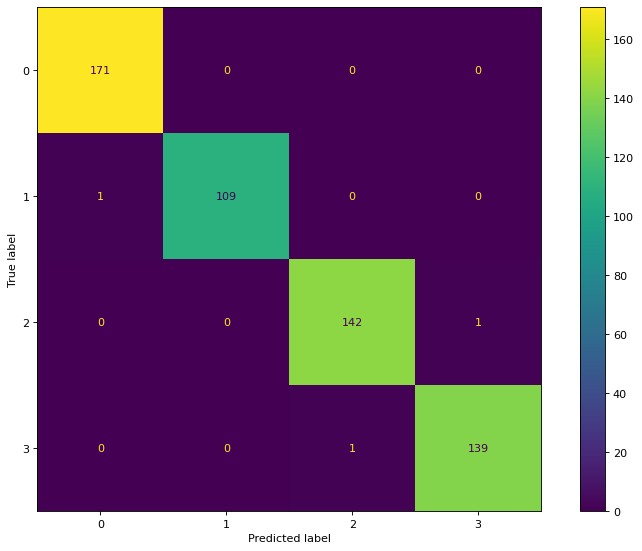

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 7), dpi=80)

cmp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(expected, predicted),
    display_labels=SatelliteDataset.CLASSES.values(),
)

cmp.plot(ax=ax)

fig.tight_layout()
fig.savefig('./images/confusion_matrix.png', bbox_inches='tight')